# Financial Planning After Widowhood

## A Python Case Study on Income Loss, Insurance, Advisor Support, and Financial Stress

Widowhood can change a person's financial life quickly, yet its financial impacts are not always examined through data.

This case study uses Python to explore how income disruption, financial preparedness, insurance, and advisor support may relate to financial stress after widowhood.

The dataset used in this project is simulated for learning purposes and does not represent real individuals. The goal is to practice applying Python to financial planning analysis and translate the results into practical recommendations for a surviving spouse.


## Background

This work draws on nearly 25 years of experience as a financial advisor, adding a real-world financial planning perspective to the data-driven analysis.

This topic really hits home. An unexpected medical illness struck my family, and I went from wife to widow in what felt like a split second. At the time, I was only in my 40s, had returned to work just four years earlier, and was suddenly faced with supporting our children on my own.

That experience shaped my interest in how data can help explain the financial pressure a surviving spouse may face, especially when life-altering decisions must be made while emotions are running high.

Because the topic is personally meaningful, I wanted the analysis to balance technical work with practical planning concerns.




## Case Study Question

How do income loss, savings, insurance, and financial advisor support relate to financial stress after widowhood?


## Dataset Description

This case study uses a simulated dataset of 200 widowed individuals. The dataset includes variables such as age, income before and after loss, savings, financial advisor status, time since loss, post-loss expenses, insurance payout, current net worth, income loss, and a financial stress score.

The financial stress score is measured on a scale where higher values indicate greater financial stress.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set seed so the simulated data is repeatable
np.random.seed(42)

# Number of simulated individuals
n = 200

# Create simulated dataset
df = pd.DataFrame({
    "age": np.random.randint(40, 80, n),
    "income_pre": np.random.randint(40000, 120000, n),
    "savings_pre": np.random.randint(50000, 500000, n),
    "has_advisor": np.random.choice(["Yes", "No"], n),
    "time_since_loss_years": np.round(np.random.uniform(0.5, 10, n), 1)
})

# Income after loss drops between 20% and 50%
df["income_post"] = df["income_pre"] * np.random.uniform(0.5, 0.8, n)

# Expenses are reduced, but not as much as income
df["expenses_post"] = df["income_post"] * np.random.uniform(0.7, 0.95, n)

# Some individuals receive insurance payouts
df["insurance_payout"] = np.random.choice([0, 50000, 100000, 200000], n)

# Current net worth after expenses over time
df["net_worth_current"] = (
    df["savings_pre"]
    + df["insurance_payout"]
    - (df["expenses_post"] * df["time_since_loss_years"])
)

# Income loss
df["income_loss"] = df["income_pre"] - df["income_post"]

# Financial stress score, where higher means more stress
df["financial_stress_score"] = np.round(
    (df["income_loss"] / df["income_pre"]) * 10
    + np.random.uniform(0, 2, n),
    1
)

# Prevent negative net worth values
df["net_worth_current"] = df["net_worth_current"].clip(lower=0)

df.head()

,age,income_pre,savings_pre,has_advisor,time_since_loss_years,income_post,expenses_post,insurance_payout,net_worth_current,income_loss,financial_stress_score
0,78,82107,194356,Yes,8.8,51860.702719,42752.211648,200000,18136.537498,30246.297281,4.6
1,68,91663,253861,Yes,7.7,61711.737215,54309.454165,100000,0.000000,29951.262785,4.3
2,54,55708,405612,No,0.9,33792.959440,24555.474284,0,383512.073144,21915.040560,4.0
3,47,89811,59435,No,3.1,55453.319940,40758.447163,0,0.000000,34357.680060,5.4
4,60,42811,497556,Yes,0.7,28236.305169,21626.777698,0,482417.255611,14574.694831,4.0


## Data Preview

The table above shows the first five rows of the simulated dataset. Each row represents one widowed individual. The columns include income before and after loss, savings, advisor status, time since loss, expenses, insurance payout, current net worth, income loss, and financial stress score.


In [2]:
# Summary statistics for the main financial variables
summary_columns = [
    "age",
    "income_pre",
    "income_post",
    "income_loss",
    "savings_pre",
    "expenses_post",
    "insurance_payout",
    "net_worth_current",
    "financial_stress_score"
]

df[summary_columns].describe().round(2)


,age,income_pre,income_post,income_loss,savings_pre,expenses_post,insurance_payout,net_worth_current,financial_stress_score
count,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00
mean,59.58,78746.78,51569.17,27177.61,256978.48,42849.09,90000.00,156287.94,4.43
std,12.03,24014.80,16870.12,10889.39,132450.26,14954.73,74685.27,155449.23,0.99
min,40.00,40301.00,21730.59,9745.20,51542.00,15825.39,0.00,0.00,2.30
25%,48.00,56833.50,37167.86,18996.41,139502.00,29868.89,37500.00,0.00,3.70
50%,61.00,80791.00,51521.92,26187.29,246228.00,42229.03,100000.00,115527.99,4.40
75%,71.00,96865.75,64207.89,33950.95,380843.75,54938.99,200000.00,258426.99,5.12
max,79.00,119909.00,90846.13,56142.79,497556.00,83012.50,200000.00,592796.33,6.70


## Summary Statistics

The summary statistics provide an overview of the simulated data. Shown are the average, minimum, maximum, and spread of the main financial variables, including income, savings, expenses, insurance payout, current net worth, and financial stress score.

This helps establish a baseline before comparing different groups in the dataset.


## Advisor Analysis

This section compares widowed individuals who have financial advisor support with those who do not. The comparison looks at group averages for financial stress, income loss, and current net worth, along with the number of individuals in each group.

The goal is to explore whether advisor support may be associated with differences in financial stress after widowhood.

In [3]:
advisor_summary = df.groupby("has_advisor").agg(
    average_stress=("financial_stress_score", "mean"),
    average_income_loss=("income_loss", "mean"),
    average_net_worth=("net_worth_current", "mean"),
    count=("has_advisor", "count")
).round(2)

advisor_summary


,average_stress,average_income_loss,average_net_worth,count
has_advisor,,,,
No,4.59,27939.82,157525.07,89
Yes,4.29,26566.47,155296.02,111


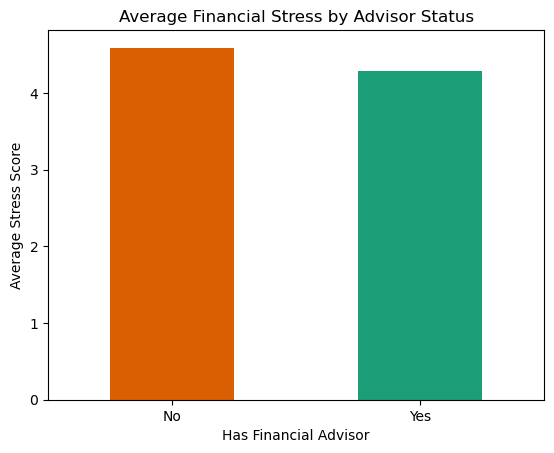

In [4]:
advisor_summary["average_stress"].plot(
    kind="bar",
    color=["#d95f02", "#1b9e77"]
)

plt.title("Average Financial Stress by Advisor Status")
plt.xlabel("Has Financial Advisor")
plt.ylabel("Average Stress Score")
plt.xticks(rotation=0)
plt.show()


### Advisor Analysis Interpretation

In this simulated dataset, individuals with financial advisors showed a slightly lower average financial stress score than individuals without advisors. This does not prove that financial advisors reduce stress, but it does suggest that professional guidance may be an important planning factor to consider.

After widowhood, a surviving spouse may need to make decisions about income replacement, insurance, household expenses, debt, investments, taxes, and long-term financial security. Advisor support may help organize those decisions and provide structure during a period when financial and emotional stress often occur together.



## Income Loss Analysis

This section examines whether income loss is related to financial stress after widowhood. Income may decrease quickly after the loss of a spouse, while household expenses may not decline at the same pace.

The analysis uses a scatter plot and correlation value to evaluate whether larger income losses are associated with higher financial stress scores.


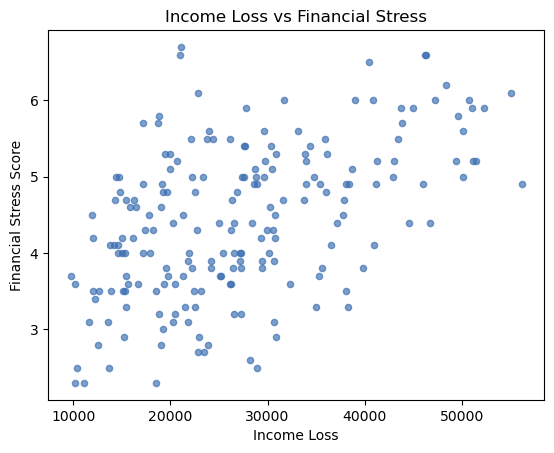

Correlation between income loss and financial stress: 0.505


In [5]:
df.plot.scatter(
    x="income_loss",
    y="financial_stress_score",
    alpha=0.65,
    color="#386cb0"
)

plt.title("Income Loss vs Financial Stress")
plt.xlabel("Income Loss")
plt.ylabel("Financial Stress Score")
plt.show()

income_stress_correlation = df["income_loss"].corr(df["financial_stress_score"])
print("Correlation between income loss and financial stress:", round(income_stress_correlation, 3))


### Income Loss Interpretation

The scatter plot and correlation value help evaluate whether financial stress increases as income loss increases. In this simulated dataset, income loss shows a positive relationship with financial stress, which suggests that a sudden income gap may add pressure after the loss of a spouse.

From a planning perspective, this reinforces the importance of reviewing cash flow early. A surviving spouse may need to evaluate income sources, household expenses, emergency reserves, survivor benefits, insurance, and any spending adjustments needed to maintain stability.


## Insurance Payout Analysis

This section examines whether insurance is associated with lower financial stress or higher current net worth. Insurance may provide short-term financial stability after the loss of a spouse, but long-term outcomes may also depend on current expenses, broader financial resources, income replacement, and planning decisions.



In [6]:
insurance_summary = df.groupby("insurance_payout").agg(
    average_stress=("financial_stress_score", "mean"),
    average_net_worth=("net_worth_current", "mean"),
    count=("insurance_payout", "count")
).round(2)

insurance_summary


,average_stress,average_net_worth,count
insurance_payout,,,
0,4.34,81682.81,50
50000,4.51,136687.29,44
100000,4.56,158486.61,54
200000,4.31,242325.59,52


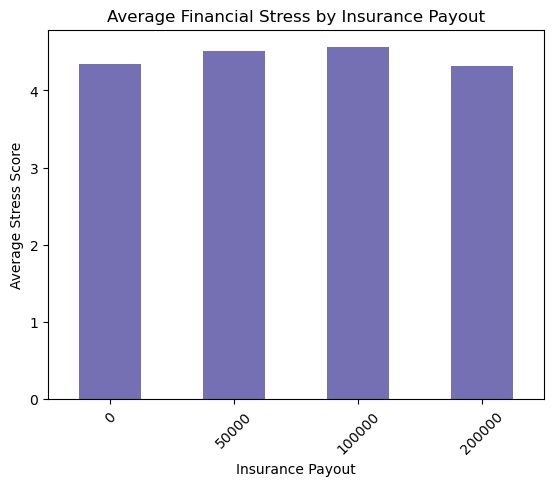

In [7]:
insurance_summary["average_stress"].plot(
    kind="bar",
    color="#7570b3"
)

plt.title("Average Financial Stress by Insurance Payout")
plt.xlabel("Insurance Payout")
plt.ylabel("Average Stress Score")
plt.xticks(rotation=45)
plt.show()


### Insurance Payout Interpretation
The insurance analysis compares average financial stress across different insurance levels. In this simulated dataset, the results show that insurance is only one part of the financial picture.

A surviving spouse may still face pressure if ongoing expenses, income replacement, debt, housing, or long-term planning needs are not addressed. For that reason, insurance should be viewed as one planning resource rather than a complete financial plan.


## Net Worth Analysis

This section examines which financial elements are most closely related to current net worth. Correlation is used to identify which variables tend to rise and fall with net worth, including savings, income, expenses, insurance payout, time since loss, and financial stress.



In [ ]:
net_worth_correlations = df[
    [
        "age",
        "income_pre",
        "income_post",
        "income_loss",
        "savings_pre",
        "expenses_post",
        "insurance_payout",
        "time_since_loss_years",
        "financial_stress_score",
        "net_worth_current"
    ]
].corr(numeric_only=True)["net_worth_current"].sort_values(ascending=False)

net_worth_correlations.round(3)


In [ ]:
net_worth_correlations.drop("net_worth_current").plot(
    kind="barh",
    color="#4daf4a"
)

plt.title("Correlation With Current Net Worth")
plt.xlabel("Correlation")
plt.ylabel("Financial Factor")
plt.show()


### Net Worth Interpretation

The net worth correlation analysis shows which financial factors have the strongest relationship with current net worth in the simulated dataset.

Positive correlations suggest that as one variable rises, current net worth also tends to rise. Negative correlations suggest that as one variable rises, current net worth tends to fall.

This helps identify which factors may be most important when creating a financial planning strategy tailored to life after widowhood.



## Key Findings

Based on the simulated financial planning dataset, several patterns appeared:

1. Individuals with financial advisors showed a slightly lower average financial stress score than those without advisors. This may suggest that advisor support is associated with lower financial stress in this simulated sample.
2. Income loss appeared to have a relationship with financial stress, suggesting that larger income reductions may increase financial pressure.
3. Insurance proceeds may support current net worth, but they do not create long-term financial stability by themselves.
4. Current net worth appears to be influenced by multiple factors, including savings, expenses, insurance, time since loss, and income changes.

Because this dataset is simulated, the findings should not be interpreted as real-world advice or evidence from actual individuals.


## Recommendations

Based on the analysis, financial planning after widowhood should begin with stabilization before moving to a long-term strategy. A surviving spouse may be facing income disruption, emotional stress, unfamiliar financial decisions, and responsibility for household or family needs at the same time.

First, establish a clear cash flow picture. This includes reviewing income sources, mandatory expenses, discretionary expenses, survivor benefits, insurance, debt obligations, and any immediate liquidity needs. Understanding the income gap is essential before making major financial decisions.

Second, protect short-term reserves. Emergency savings can provide time and flexibility while the surviving spouse evaluates next steps. Preserving liquidity may help reduce the pressure to make rushed decisions about housing, investments, insurance proceeds, or retirement assets.

Third, connect insurance proceeds to a broader financial plan. Insurance may provide important support, but it should be coordinated with debt management, housing needs, healthcare costs, taxes, education or family obligations, retirement income, and long-term investment planning.

Fourth, evaluate income replacement and long-term sustainability. This may include employment income, Social Security or survivor benefits, pension decisions, retirement account withdrawals, investment income, and realistic spending assumptions.

Finally, professional financial guidance may prove valuable when complex decisions arise, particularly during emotionally difficult times. Advisor support can help organize accounts, evaluate tradeoffs, manage risk, and create a plan that supports both immediate stability and long-term financial security. It can also help distinguish between decisions that require timely action and reactionary decisions that may create long-term harm.


## Limitations

This case study uses simulated data, so the results do not represent real widowed individuals or real client outcomes. The dataset was created for learning, portfolio development, and Python analysis practice.

The financial stress score is also simulated and based on simplified assumptions. In real life, financial stress can be affected by many factors not included in this dataset, such as health, dependents, housing situation, debt, family support, employment status, grief, taxes, estate issues, and access to professional advice.

Because of these limitations, the analysis should be viewed as a Python-based financial planning example rather than a real-world research conclusion. The findings show patterns within the simulated dataset, but they do not prove cause and effect or represent financial advice.



## Conclusion

This case study used Python to explore financial planning after widowhood using a simulated dataset. The analysis examined income loss, savings, insurance, financial advisor support, current net worth, and financial stress.

The results show how Python can be used to organize financial data, calculate summary statistics, compare groups, create visualizations, and support planning-focused recommendations.

Although the data is simulated, the project demonstrates an important financial planning process: identify the problem, analyze the data, interpret the patterns, and make recommendations that support both short-term stability and long-term financial security.

The broader takeaway is that widowhood can create both emotional and financial disruption. A structured planning process can help clarify decisions, identify pressure points, and support a path forward during a difficult transition.
